Print out the basic statistics for all variables of the data. For numeric data, this should include the mean, median, mode, range, standard deviation, and interquartile (25%, 50%, 75%) range. For categorical data, it should include the number of unique values.


For the two variables you choose to explore, complete the following:

Why are you choosing these variables?
How do they relate to your research question?
What do you learn about them from the initial variable information printed above, and how does it relate to your research?
For the two variables you chose, calculate the skew and kurtosis for each of these variables.
What do these statistics tell you about the distribution of these variables?
Visualize one variable in a histogram.
Visualize the other as multiple box plots separated by a categorical column in the data.
Explain why you made the choices you did for the visualizations.
Interpret the results of both the statistics and the visualizations in relation to your research question.
Remember to use markdown cells for the written portions of the assignments.


In [43]:
import pandas as pd 
import scipy.stats as stats

df = pd.read_csv('/Users/hallevidak/Downloads/Felony_Sentences.csv')
print(df.head())

   OBJECTID  RID  GENERIC_CASE_ID  GENERIC_OFFENDER_ID  CHARGE_NUMBER  \
0         1   39          7548270              7241253              3   
1         2   40          7548270              7241253              7   
2         3   41          2815732              5135695              3   
3         4   42          2815732              5135695              4   
4         5   43          7703087              7383706              1   

   SENTENCE_YEAR   RACE GENDER AGE_GROUP  \
0           2020  Black      M     22-30   
1           2020  Black      M     22-30   
2           2020  Black      M     22-30   
3           2020  Black      M     22-30   
4           2020  Black      F     61-70   

                                             OFFENSE  ... VVCA_AMT FINE_AMT  \
0                       Aggravated Assault Knowingly  ...      100      NaN   
1                   Unlawful Possession of a Firearm  ...      100      NaN   
2  Unlawful Possession of a Firearm (Crime of Vio...  ...  

In [44]:
print(df.columns)

Index(['OBJECTID', 'RID', 'GENERIC_CASE_ID', 'GENERIC_OFFENDER_ID',
       'CHARGE_NUMBER', 'SENTENCE_YEAR', 'RACE', 'GENDER', 'AGE_GROUP',
       'OFFENSE', 'OFFENSE_TYPE', 'HOMICIDE_TYPE', 'OFFENSE_SEVERITY_GROUP',
       'SENTENCE_TYPE', 'SENTENCE_IMPOSED_MONTHS', 'SENTENCE_SUSPENDED_MONTHS',
       'SENTENCE_TO_SERVE_MONTHS', 'SENTENCE_PROBATION_MONTHS', 'VVCA_AMT',
       'FINE_AMT', 'RESTITUTION_AMT', 'FINE_SUSPENDED_AMT', 'GIS_ID',
       'GLOBALID', 'CREATOR', 'CREATED', 'EDITOR', 'EDITED'],
      dtype='object')


In [45]:

        
for col in df.columns:
    print(f"\nColumn: {col}")
    
    if pd.api.types.is_numeric_dtype(df[col]):
        print("NUMERIC")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())
        print("Mode:", df[col].mode())
        print("Range:", df[col].max() - df[col].min())
        print("Standard Deviation:", df[col].std())
        print("25th Percentile:", df[col].quantile(0.25))
        print("50th Percentile:", df[col].quantile(0.50))
        print("75th Percentile:", df[col].quantile(0.75))
        
    else:
        print("Number of Unique Values:", df[col].nunique())
        print("CATEGORICAL")
              


Column: OBJECTID
NUMERIC
Mean: 12338.5
Median: 12338.5
Mode: 0            1
1            2
2            3
3            4
4            5
         ...  
24671    24672
24672    24673
24673    24674
24674    24675
24675    24676
Name: OBJECTID, Length: 24676, dtype: int64
Range: 24675
Standard Deviation: 7123.491957366602
25th Percentile: 6169.75
50th Percentile: 12338.5
75th Percentile: 18507.25

Column: RID
NUMERIC
Mean: 12338.5
Median: 12338.5
Mode: 0            1
1            2
2            3
3            4
4            5
         ...  
24671    24672
24672    24673
24673    24674
24674    24675
24675    24676
Name: RID, Length: 24676, dtype: int64
Range: 24675
Standard Deviation: 7123.491957366602
25th Percentile: 6169.75
50th Percentile: 12338.5
75th Percentile: 18507.25

Column: GENERIC_CASE_ID
NUMERIC
Mean: 4985361.820959637
Median: 4971251.5
Mode: 0    2598483
Name: GENERIC_CASE_ID, dtype: int64
Range: 9998365
Standard Deviation: 2895654.8273563716
25th Percentile: 2448698.75
50

In [46]:
# SENTENCED TO SERVE
print("Skew (TO SERVE):", stats.skew(df['SENTENCE_TO_SERVE_MONTHS'].dropna()))
print("Kurtosis (TO SERVE):", stats.kurtosis(df['SENTENCE_TO_SERVE_MONTHS'].dropna()))

# SENTENCE IMPOSED
print("Skew (IMPOSED):", stats.skew(df['SENTENCE_IMPOSED_MONTHS'].dropna()))
print("Kurtosis (IMPOSED):", stats.kurtosis(df['SENTENCE_IMPOSED_MONTHS'].dropna()))

Skew (TO SERVE): 4.9481519576268145
Kurtosis (TO SERVE): 35.57163165354083
Skew (IMPOSED): 5.240947984095946
Kurtosis (IMPOSED): 38.94255233777204


Why are you choosing these variables?

- I chose SENTENCE_TO_SERVE_MONTHS and SENTENCE_IMPOSED_MONTHS because both variables measure sentencing outcomes in months. These variables allow for a direct comparison between the total sentence given and the portion that must actually be served, making them highly relevant for analyzing sentencing patterns. I also chose them because they are both numerical categories, so I can perform the required stat tests, like kurtosis and skew, on them.

How do they relate to your research question?

- These variables relate to my research question because they help me evaluate how sentencing decisions are implemented. By comparing imposed sentences to actual time served, I can identify whether sentences are consistently reduced and how sentencing severity varies across each case.

What do you learn about them from the initial variable information printed above, and how does it relate to your research?

- From the initial variable information, I can see that both SENTENCE_TO_SERVE_MONTHS and SENTENCE_IMPOSED_MONTHS are numerical variables measured in months. I also noticed there are other related sentencing variables, which shows that sentences can be split into different parts.
This relates to my research because it confirms that the sentence given is not always the same as the time actually served. That difference is important for understanding how sentencing decisions are applied.

For the two variables you chose, calculate the skew and kurtosis for each of these variables.

(completed above)

What do these statistics tell you about the distribution of these variables?

- The skewness values show that both variables are positively skewed, meaning most sentences are on the shorter side, with a few much longer sentences pulling the distribution to the right.
The kurtosis values suggest that there are some extreme values in the data, meaning a small number of cases have unusually high sentence lengths.
Overall, this tells me that sentencing is not evenly distributed and that while most cases result in shorter sentences, there are some outliers with much longer ones.

Visualize one variable in a histogram.

(completed below)

Visualize the other as multiple box plots separated by a categorical column in the data.

(completed below)

Explain why you made the choices you did for the visualizations.

- I used a histogram for sentence-to-serve months to understand its overall distribution, including skewness and the presence of outliers. I used box plots for sentence imposed months grouped by offense severity to compare how sentencing varies across different levels of crime seriousness. This allows for clearer comparisons between groups. 

Interpret the results of both the statistics and the visualizations in relation to your research question.

- Based on one of my research questions about how sentencing decisions are implemented, these results show that the "typical" experience in the justice system is generally consistent, aside from the apparent outliers. The histogram and the positive skew confirm that the vast majority of cases result in shorter sentences (under 100 months), which suggests that most offenses being processed are on the lower end of the severity scale. However, the high kurtosis and the long "tail" in the data show that when we get into more serious crimes, the sentences become longer and more unpredictable. Looking at the box plots, the offense severity moves toward groups like M1, the median sentence jumps up significantly, and the spread of the data gets much wider. This tells me that while the offense category is a huge factor, there are potentially other aspects affecting sentencing, like a defendant's prior record or specific case details—that cause those extreme outliers. Overall, the data shows that the system is mostly consistent for minor crimes, but has a large amount of variation when it comes to high-level offenses.

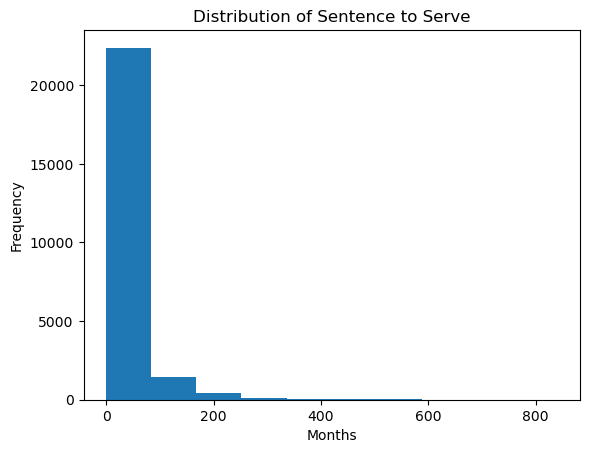

In [47]:
import matplotlib.pyplot as plt

plt.hist(df['SENTENCE_TO_SERVE_MONTHS'].dropna())
plt.title("Distribution of Sentence to Serve")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.show()

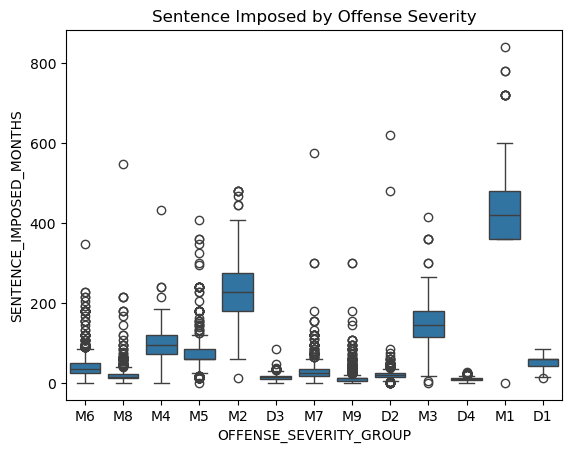

In [50]:
sns.boxplot(x='OFFENSE_SEVERITY_GROUP', y='SENTENCE_IMPOSED_MONTHS', data=df)
plt.title("Sentence Imposed by Offense Severity")
plt.show()